# Analise 2 - Confiabilidade: Escuderias com mais abandonos (DNFs)

## 1. Introdução

Na Fórmula 1, a confiabilidade dos carros é um fator tão importante quanto a velocidade. Abandonos de corrida — conhecidos como DNFs (Did Not Finish) — impactam diretamente o desempenho das equipes em uma temporada. Eles podem ocorrer por falhas mecânicas, acidentes ou outros problemas técnicos.

Esta análise busca identificar as escuderias que mais abandonaram corridas, tanto em valores absolutos quanto percentuais, considerando o total de participações.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Identificar as escuderias com maior número de abandonos (DNFs);

    - Calcular o percentual de abandonos em relação ao total de participações por escuderia;

    - Visualizar as equipes com pior confiabilidade histórica na Fórmula 1.

## 3. Metodologia

Inicialmente, foram utilizadas três bases de dados principais:

    - results.csv: informações sobre o resultado de cada piloto em cada corrida, incluindo status final;

    - constructors.csv: nomes e identificadores das escuderias;

    - status.csv: descrição textual dos status (Finished, Accident, Engine, etc.).

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [14]:
import pandas as pd

# Carregamento das bases
resultados = pd.read_csv("results.csv")
construtores = pd.read_csv("constructors.csv")
status = pd.read_csv("status.csv")

# Juntar informações de status
resultados = resultados.merge(status, on="statusId", how="left")

# Identificar DNFs (status diferente de "Finished" ou "Disqualified")
resultados["is_dnf"] = ~resultados["status"].str.contains("Finished|Disqualified", case=False, na=False)

# Juntar nome das escuderias
resultados = resultados.merge(construtores[["constructorId", "name"]], on="constructorId", how="left")

# Total de participações por escuderia
participacoes = resultados["name"].value_counts().reset_index()
participacoes.columns = ["constructor", "total_participacoes"]

# Total de DNFs por escuderia
dnfs = resultados[resultados["is_dnf"]]["name"].value_counts().reset_index()
dnfs.columns = ["constructor", "total_dnfs"]

# Combinar os dados
df_confiabilidade = participacoes.merge(dnfs, on="constructor", how="left")
df_confiabilidade["total_dnfs"] = df_confiabilidade["total_dnfs"].fillna(0).astype(int)

# Calcular percentual de DNFs
df_confiabilidade["percentual_dnfs"] = 100 * df_confiabilidade["total_dnfs"] / df_confiabilidade["total_participacoes"]

# Ordenar
df_confiabilidade = df_confiabilidade.sort_values(by="total_dnfs", ascending=False).reset_index(drop=True)

## 4. Análise de

#### 4.1 Top 10 Escuderias com Mais Abandonos (Quantidade Absoluta)

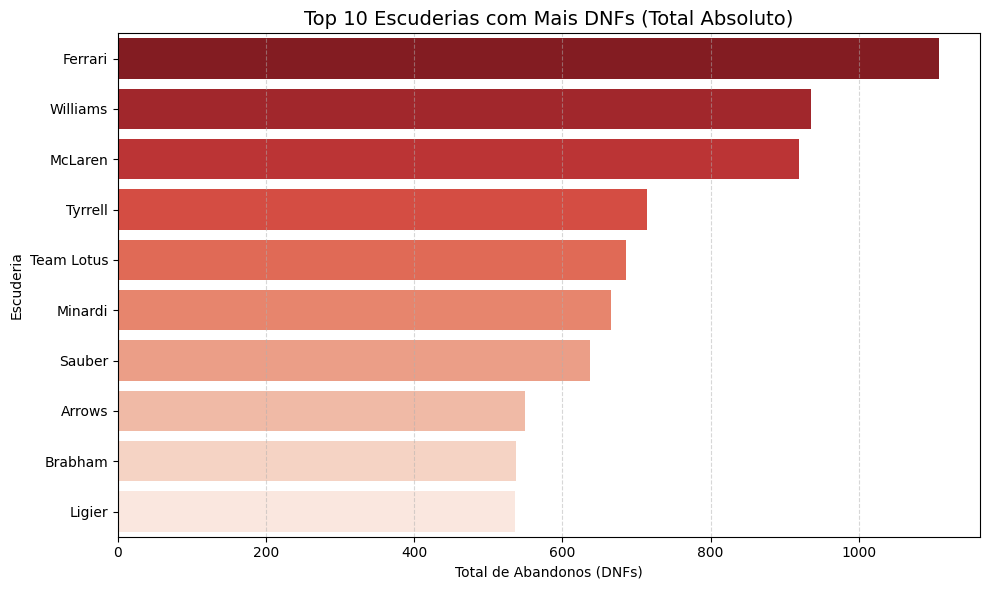

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_abs = df_confiabilidade.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_abs, x="total_dnfs", y="constructor", hue="constructor", palette="Reds_r", legend=False)
plt.title("Top 10 Escuderias com Mais DNFs (Total Absoluto)", fontsize=14)
plt.xlabel("Total de Abandonos (DNFs)")
plt.ylabel("Escuderia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### 4.2 Top 10 Escuderias com Maior Percentual de DNFs

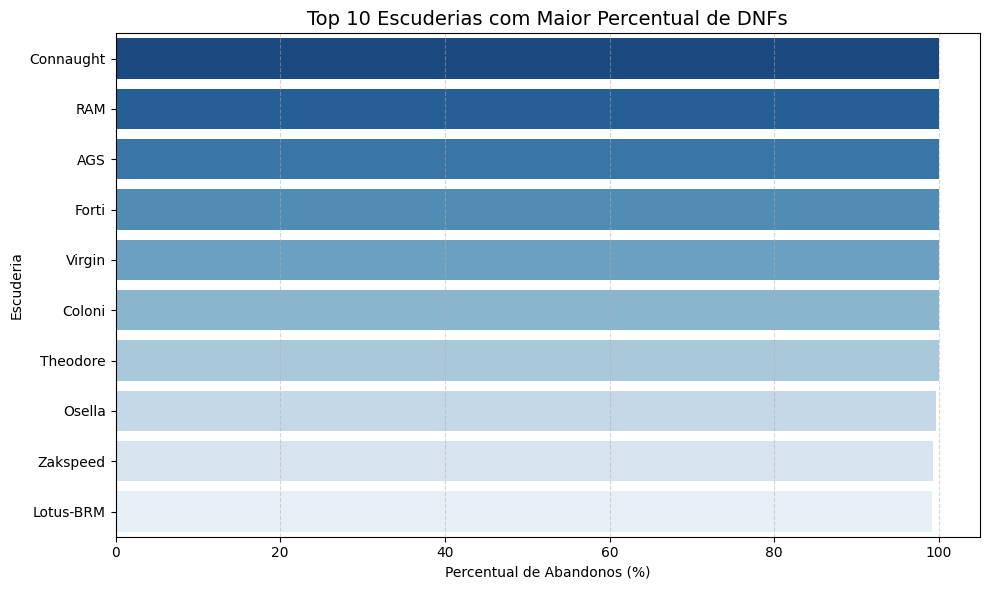

In [8]:
# Considera apenas escuderias com pelo menos 50 corridas para evitar distorções
df_pct = df_confiabilidade[df_confiabilidade["total_participacoes"] >= 50]
top10_pct = df_pct.sort_values("percentual_dnfs", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top10_pct, x="percentual_dnfs", y="constructor", hue="constructor", palette="Blues_r", legend=False)
plt.title("Top 10 Escuderias com Maior Percentual de DNFs", fontsize=14)
plt.xlabel("Percentual de Abandonos (%)")
plt.ylabel("Escuderia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Conclusão

A análise revelou que:

    - Escuderias com longa história na Fórmula 1 acumulam naturalmente mais abandonos absolutos, como Lotus, Ferrari e McLaren.

    - No entanto, equipes menores ou menos competitivas tendem a apresentar os maiores percentuais de abandono.

    - A confiabilidade dos carros é um fator crucial, especialmente em temporadas onde cada ponto conta.

O percentual de abandonos oferece uma métrica mais justa de comparação entre escuderias com diferentes números de participações.